# 📊 NOTEBOOK 01 — Exploration du Dataset Flipkart
## Objectifs
1. Comprendre la structure du CSV Flipkart
2. Visualiser la distribution des catégories
3. Analyser les images (tailles, qualité, exemples)
4. Identifier les problèmes avant modélisation

> **Ce notebook ne modifie aucune donnée.** Il sert uniquement à comprendre ce qu'on a.

## 1. Imports & Configuration

In [18]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

# ── Chemins ────────────────────────────────────────────────────────────────
# Adapte ces chemins à ton dossier data/raw/
CSV_PATH    = "../data/raw/flipkart.csv"
IMAGES_DIR  = "../data/raw/images/"   # dossier contenant les images produits

# ── Style ──────────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("✅ Imports OK")
print(f"   CSV    : {CSV_PATH}")
print(f"   Images : {IMAGES_DIR}")


✅ Imports OK
   CSV    : ../data/raw/flipkart.csv
   Images : ../data/raw/images/


## 2. Chargement du CSV

In [19]:
df = pd.read_csv(CSV_PATH)
print(f"Shape : {df.shape}  →  {df.shape[0]} produits, {df.shape[1]} colonnes")
print("\nColonnes :")
for col in df.columns:
    pct_null = df[col].isna().mean()*100
    print(f"  {col:45} | {pct_null:.1f}% nuls")


Shape : (1050, 15)  →  1050 produits, 15 colonnes

Colonnes :
  uniq_id                                       | 0.0% nuls
  crawl_timestamp                               | 0.0% nuls
  product_url                                   | 0.0% nuls
  product_name                                  | 0.0% nuls
  product_category_tree                         | 0.0% nuls
  pid                                           | 0.0% nuls
  retail_price                                  | 0.1% nuls
  discounted_price                              | 0.1% nuls
  image                                         | 0.0% nuls
  is_FK_Advantage_product                       | 0.0% nuls
  description                                   | 0.0% nuls
  product_rating                                | 0.0% nuls
  overall_rating                                | 0.0% nuls
  brand                                         | 32.2% nuls
  product_specifications                        | 0.1% nuls


In [20]:
df.head(3)


,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."


In [21]:
# ─── COLONNE DU CSV ─────────────────────────────────────────
# Adapte si les noms de colonnes diffèrent dans ton CSV
CAT_COL    = "product_category_tree"  # colonne des catégories
IMG_COL    = "image"   

# ⚠️  Adapte ces deux chemins à ton installation
CSV_PATH   = "../data/raw/flipkart_com-ecommerce_sample_1050.csv"
IMG_DIR    = "../data/raw/images/"

## 3. Extraction de la catégorie principale

In [22]:
# Le champ ressemble à : ["Watches >> Accessories >> ..."]
# On extrait le premier niveau
df["category"] = (df[CAT_COL]
                  .str.extract(r'\["([^">>]+)')
                  .iloc[:, 0]
                  .str.strip())

# Affichage
cat_counts = df["category"].value_counts()
print(f"Catégories trouvées : {len(cat_counts)}")
print("\nDistribution :")
for cat, n in cat_counts.items():
    bar = "█" * int(n / cat_counts.max() * 30)
    print(f"  {cat:40} {bar} {n}")


Catégories trouvées : 7

Distribution :
  Home Furnishing                          ██████████████████████████████ 150
  Baby Care                                ██████████████████████████████ 150
  Watches                                  ██████████████████████████████ 150
  Home Decor & Festive Needs               ██████████████████████████████ 150
  Kitchen & Dining                         ██████████████████████████████ 150
  Beauty and Personal Care                 ██████████████████████████████ 150
  Computers                                ██████████████████████████████ 150


## 4. Visualisation de la distribution

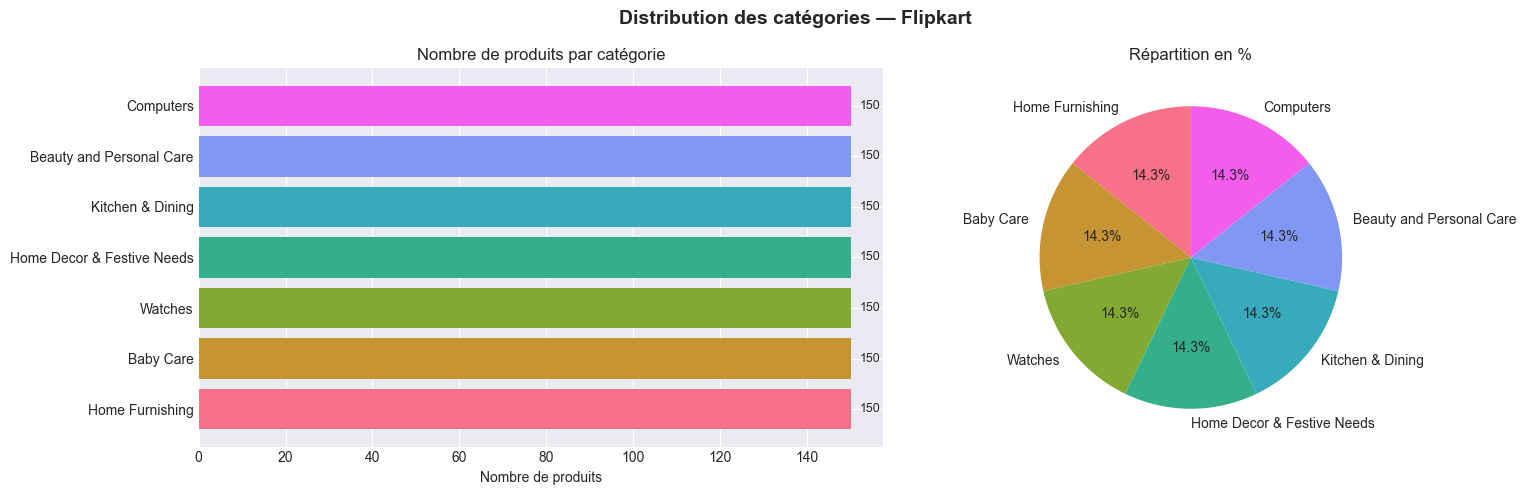

💾 Sauvegardé → outputs/plots/01_class_distribution.png


In [23]:
os.makedirs("../outputs/plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Distribution des catégories — Flipkart", fontsize=14, fontweight="bold")

palette = sns.color_palette("husl", len(cat_counts))

# Barplot
bars = axes[0].barh(cat_counts.index, cat_counts.values, color=palette)
axes[0].set_title("Nombre de produits par catégorie")
axes[0].set_xlabel("Nombre de produits")
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# Pie
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            autopct="%1.1f%%", colors=palette, startangle=90)
axes[1].set_title("Répartition en %")

plt.tight_layout()
plt.savefig("../outputs/plots/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Sauvegardé → outputs/plots/01_class_distribution.png")


## 5. Vérification des images sur disque

In [24]:
df["img_path"] = df[IMG_COL].apply(lambda x: os.path.join(IMG_DIR, str(x)))
df["img_exists"] = df["img_path"].apply(os.path.exists)

print(f"Images trouvées    : {df['img_exists'].sum()}")
print(f"Images manquantes  : {(~df['img_exists']).sum()}")
print(f"Taux de couverture : {df['img_exists'].mean()*100:.1f}%")


Images trouvées    : 1050
Images manquantes  : 0
Taux de couverture : 100.0%


## 6. Analyse des dimensions d'images

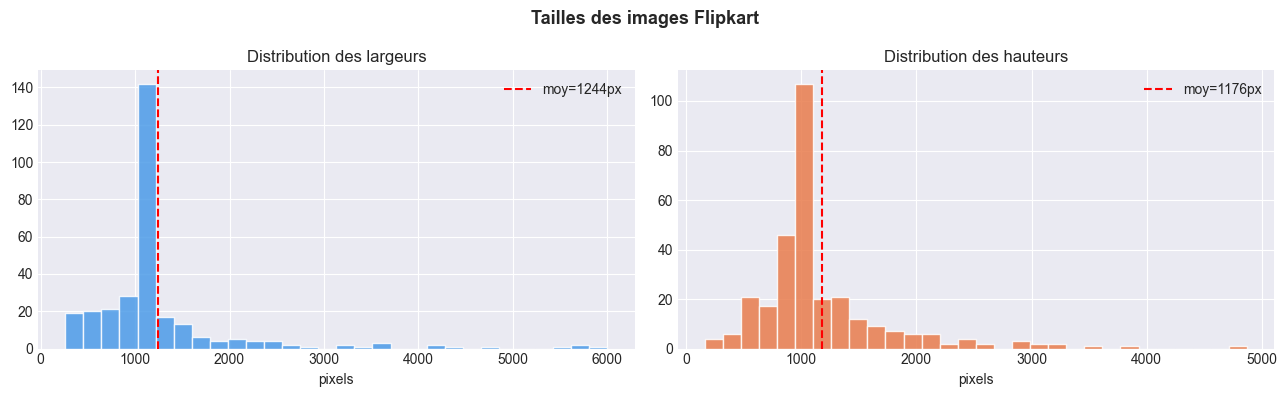

Largeur  → min=261  max=6000  moy=1244
Hauteur  → min=160 max=4872 moy=1176

→ On choisira IMG_SIZE=(96,96) : bon compromis pour ~1050 images


In [25]:
valid_paths = df[df["img_exists"]]["img_path"].values[:300]
widths, heights = [], []

for p in valid_paths:
    try:
        img = Image.open(p)
        widths.append(img.width)
        heights.append(img.height)
    except:
        pass

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(widths,  bins=30, color="#4C9BE8", edgecolor="white", alpha=0.85)
axes[0].axvline(np.mean(widths), color="red", ls="--", label=f"moy={np.mean(widths):.0f}px")
axes[0].set_title("Distribution des largeurs"); axes[0].set_xlabel("pixels"); axes[0].legend()

axes[1].hist(heights, bins=30, color="#E87C4C", edgecolor="white", alpha=0.85)
axes[1].axvline(np.mean(heights), color="red", ls="--", label=f"moy={np.mean(heights):.0f}px")
axes[1].set_title("Distribution des hauteurs"); axes[1].set_xlabel("pixels"); axes[1].legend()

plt.suptitle("Tailles des images Flipkart", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/plots/01_image_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Largeur  → min={min(widths)}  max={max(widths)}  moy={np.mean(widths):.0f}")
print(f"Hauteur  → min={min(heights)} max={max(heights)} moy={np.mean(heights):.0f}")
print("\n→ On choisira IMG_SIZE=(96,96) : bon compromis pour ~1050 images")


## 7. Exemples visuels par catégorie

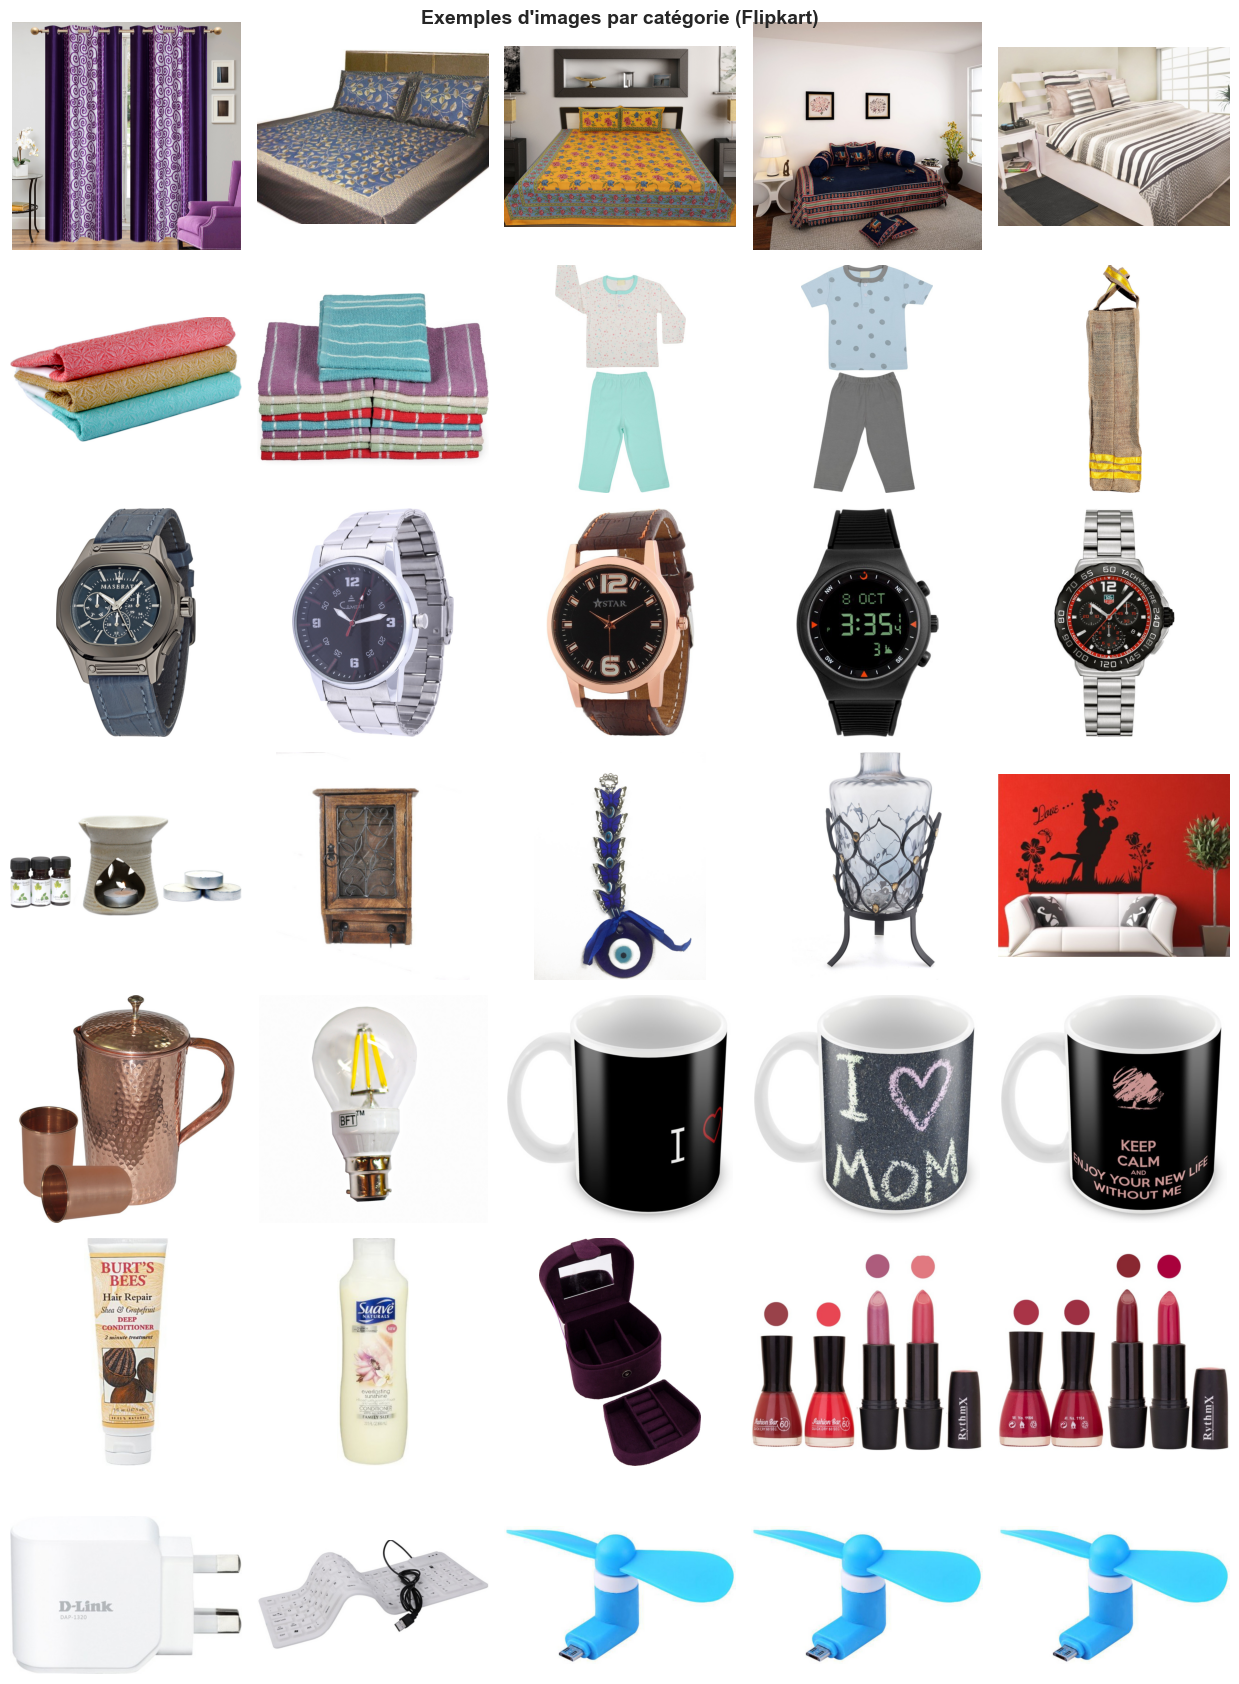

In [26]:
categories = df["category"].dropna().unique()[:7]
n_per_cat  = 5

fig, axes = plt.subplots(len(categories), n_per_cat,
                          figsize=(n_per_cat*2.5, len(categories)*2.5))
fig.suptitle("Exemples d'images par catégorie (Flipkart)", fontsize=14, fontweight="bold")

for row, cat in enumerate(categories):
    subset = df[(df["category"]==cat) & df["img_exists"]]
    for col in range(n_per_cat):
        ax = axes[row][col]
        if col < len(subset):
            try:
                ax.imshow(Image.open(subset["img_path"].iloc[col]).convert("RGB"))
            except:
                ax.set_facecolor("#333")
        else:
            ax.set_facecolor("#333")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cat[:22], rotation=0, labelpad=90, va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/plots/01_samples_per_category.png", dpi=150, bbox_inches="tight")
plt.show()


## ✅ Résumé

In [27]:
print("="*60)
print("  RÉSUMÉ — NOTEBOOK 01")
print("="*60)
print(f"  Produits total       : {len(df)}")
print(f"  Catégories           : {df['category'].nunique()}")
print(f"  Images trouvées      : {df['img_exists'].sum()}")
print(f"  Images manquantes    : {(~df['img_exists']).sum()}")
print()
print("  ⚙️  Paramètres retenus pour la suite :")
print("     IMG_SIZE = (96, 96)  ← taille uniforme pour tous les modèles")
print("     Test    = 20%")
print("     Val     = 15%")
print("     Train   = 65%")
print("="*60)
print()
print("→ Exécuter ensuite : 02_preprocessing.ipynb")


  RÉSUMÉ — NOTEBOOK 01
  Produits total       : 1050
  Catégories           : 7
  Images trouvées      : 1050
  Images manquantes    : 0

  ⚙️  Paramètres retenus pour la suite :
     IMG_SIZE = (96, 96)  ← taille uniforme pour tous les modèles
     Test    = 20%
     Val     = 15%
     Train   = 65%

→ Exécuter ensuite : 02_preprocessing.ipynb
